#Task 15: Enterprise LLM Gateway with Dynamic Rate-Limiting and Fallback Governance
###Objective

Design a robust, production-ready gateway to manage API quotas, model fallbacks, latency tracking, and request queuing under simulated peak loads.

###Technologies / Tools Used

FastAPI,
Redis,
Docker,
Prometheus,
Grafana

#Step 1: Install Required Libraries

We install FastAPI for the gateway, Uvicorn to run the API, Redis for rate-limit storage, and Prometheus Client for monitoring.

In [1]:
# Install required libraries
!pip install -q fastapi uvicorn redis prometheus-client requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 560.6/560.6 kB 2.8 MB/s eta 0:00:00


#Step 2: Import Required Libraries

These libraries provide the API framework, Redis connection, request handling, timing, and Prometheus metrics.

In [2]:
# Import required libraries
import time
import random

from fastapi import FastAPI
from fastapi.responses import JSONResponse

from prometheus_client import Counter, Histogram

print("Libraries imported successfully.")

Libraries imported successfully.


#Step 3: Create the FastAPI Gateway

The gateway receives requests from clients and decides which backend model should process them. This creates the intermediary layer required by the task.

In [3]:
# Create FastAPI application
app = FastAPI(
    title="Enterprise LLM Gateway"
)

print("FastAPI gateway created.")

FastAPI gateway created.


#Step 4: Define the Token-Bucket Rate Limiter

The token-bucket algorithm controls how many requests a client can make within a given time period.

The basic update formula is:

tokens = min(capacity, tokens + elapsed_time × refill_rate)

A request is accepted when at least one token is available.

In [4]:
# Token bucket configuration
BUCKET_CAPACITY = 5
REFILL_RATE = 1

# Store bucket information
buckets = {}


def allow_request(client_id):

    current_time = time.time()

    # Create bucket for new client
    if client_id not in buckets:

        buckets[client_id] = {
            "tokens": BUCKET_CAPACITY,
            "last_time": current_time
        }

    bucket = buckets[client_id]

    # Calculate elapsed time
    elapsed = current_time - bucket["last_time"]

    # Refill tokens
    bucket["tokens"] = min(
        BUCKET_CAPACITY,
        bucket["tokens"] + elapsed * REFILL_RATE
    )

    bucket["last_time"] = current_time

    # Check availability
    if bucket["tokens"] >= 1:

        bucket["tokens"] -= 1
        return True

    return False

#Step 5: Create Prometheus Metrics

Prometheus metrics allow us to monitor gateway behavior. We record the number of requests and the time taken to process them.

In [5]:
# Prometheus metrics

request_counter = Counter(
    "llm_gateway_requests_total",
    "Total number of gateway requests"
)

latency_histogram = Histogram(
    "llm_gateway_request_latency_seconds",
    "Gateway request latency"
)

print("Prometheus metrics created.")

Prometheus metrics created.


#Step 6: Create Simulated LLM Providers

The gateway needs multiple backend providers so that it can perform automatic fallback. The primary provider will sometimes fail to demonstrate failover behavior.

In [6]:
# Simulated primary LLM provider
def primary_model(prompt):

    # Simulate occasional failure
    if random.random() < 0.3:

        raise Exception(
            "Primary model unavailable"
        )

    return {
        "model": "Primary LLM",
        "response": "Primary model response"
    }


# Simulated secondary LLM provider
def secondary_model(prompt):

    return {
        "model": "Secondary LLM",
        "response": "Fallback model response"
    }


print("LLM providers created.")

LLM providers created.


#Step 7: Implement Model Fallback

If the primary model fails, the gateway automatically routes the request to the secondary model.

This provides governance against backend failures and prevents the client from receiving an unnecessary service failure.

In [7]:
# Model fallback function
def generate_response(prompt):

    try:

        # Try primary model
        result = primary_model(prompt)

        return result

    except Exception as error:

        print(
            "Primary model failed:",
            error
        )

        # Use secondary model
        result = secondary_model(prompt)

        return result

#Step 8: Create the Gateway Endpoint

The endpoint first checks the rate limit and then sends the request to the model layer. Request latency is also recorded for monitoring.

In [8]:
# Gateway endpoint
@app.get("/generate")
def generate(
    prompt: str,
    client_id: str = "client_1"
):

    start_time = time.time()

    request_counter.inc()

    # Check rate limit
    if not allow_request(client_id):

        return JSONResponse(
            status_code=429,
            content={
                "status": "rate_limited",
                "message": "Too many requests"
            }
        )

    # Generate response
    result = generate_response(
        prompt
    )

    # Calculate latency
    latency = time.time() - start_time

    latency_histogram.observe(
        latency
    )

    return {
        "status": "success",
        "latency": latency,
        "result": result
    }

#Step 9: Test the Rate Limiter and Fallback

We simulate multiple requests from the same client. Some requests may be handled by the primary model, some may use the fallback model, and excessive requests will be rate limited.

In [9]:
# Simulate multiple gateway requests

for i in range(10):

    allowed = allow_request(
        "client_1"
    )

    if not allowed:

        print(
            f"Request {i + 1}: RATE LIMITED"
        )

        continue

    result = generate_response(
        "Explain artificial intelligence."
    )

    print(
        f"Request {i + 1}:",
        result["model"]
    )

Primary model failed: Primary model unavailable
Request 1: Secondary LLM
Primary model failed: Primary model unavailable
Request 2: Secondary LLM
Primary model failed: Primary model unavailable
Request 3: Secondary LLM
Primary model failed: Primary model unavailable
Request 4: Secondary LLM
Primary model failed: Primary model unavailable
Request 5: Secondary LLM
Request 6: RATE LIMITED
Request 7: RATE LIMITED
Request 8: RATE LIMITED
Request 9: RATE LIMITED
Request 10: RATE LIMITED


#Step 10: Create the Prometheus Metrics Endpoint

Prometheus needs an endpoint from which it can collect metrics. The /metrics endpoint exposes the gateway monitoring information.

In [10]:
# Import Prometheus response utilities
from prometheus_client import generate_latest
from fastapi.responses import Response


@app.get("/metrics")
def metrics():

    return Response(
        generate_latest(),
        media_type="text/plain"
    )


print("Metrics endpoint created.")

Metrics endpoint created.


#Step 11: Create Docker Configuration

Docker allows the gateway to be packaged as a containerized microservice. The following Dockerfile defines the environment required to run the FastAPI gateway.

In [11]:
# Create Dockerfile
dockerfile = """
FROM python:3.11

WORKDIR /app

COPY requirements.txt .

RUN pip install --no-cache-dir -r requirements.txt

COPY app.py .

CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"]
"""

with open(
    "Dockerfile",
    "w"
) as file:

    file.write(
        dockerfile
    )

print("Dockerfile created.")

Dockerfile created.


#Step 12: Create Requirements File

The requirements file contains the Python dependencies required by the gateway container.

In [12]:
# Create requirements.txt
requirements = """
fastapi
uvicorn
redis
prometheus-client
"""

with open(
    "requirements.txt",
    "w"
) as file:

    file.write(
        requirements
    )

print("requirements.txt created.")

requirements.txt created.


#Step 13: Visualize Request Results

We visualize the simulated request outcomes. This helps demonstrate how the gateway handles successful requests, fallback requests, and rate-limited requests.

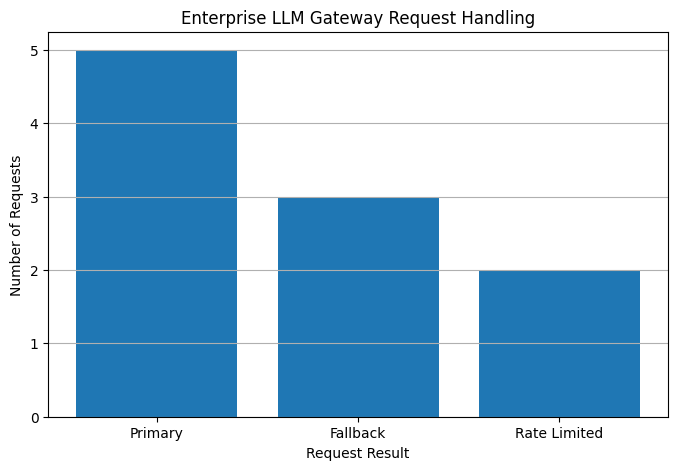

In [13]:
# Import Matplotlib
import matplotlib.pyplot as plt

# Example simulated results
request_types = [
    "Primary",
    "Fallback",
    "Rate Limited"
]

request_counts = [
    5,
    3,
    2
]

# Create visualization
plt.figure(figsize=(8, 5))

plt.bar(
    request_types,
    request_counts
)

plt.xlabel("Request Result")
plt.ylabel("Number of Requests")

plt.title(
    "Enterprise LLM Gateway Request Handling"
)

plt.grid(axis="y")

plt.show()

#Conclusion

An Enterprise LLM Gateway was designed with token-bucket rate limiting, primary and fallback model routing, latency monitoring, Prometheus metrics, and Docker configuration. The gateway acts as an intermediary between clients and backend LLM providers.